![Health-Informatics: A Python Tutorial](../../Image/chapter-banner.png)


# Module 1: What Health Informatics Is



**Health Informatics in Python** · Part I: Foundations · Module 1 of 16

---

Health informatics is the discipline concerned with how health information is
**captured, structured, stored, exchanged, and used**. It sits where information
science, computer science, and healthcare meet. This first module builds the
mental model for the whole series and gets you working with health data in Python
right away.


**Health informatics** is the discipline concerned with how health information is captured, structured, stored, exchanged, and used. It sits at the intersection of information science, computer science, and healthcare. The core questions are about the *infrastructure and flow of data*: How do we design electronic health record (EHR) systems that clinicians can actually use? How do we standardize medical terminology so a diagnosis recorded in one hospital means the same thing in another (through systems like SNOMED CT, ICD, or LOINC)? How do we make different systems talk to each other (interoperability standards like HL7 and FHIR)? How do we support clinical decision-making at the point of care? Informatics is fundamentally about representation, workflow, and getting the right information to the right person at the right time.

**Health analytics** is the application of statistical, computational, and machine-learning methods to health data in order to answer questions and drive decisions. Once informatics has captured and organized the data, analytics does something with it: predicting which patients are at risk of readmission, identifying disease clusters across a population, evaluating whether a treatment or program actually worked, forecasting hospital capacity, or estimating causal effects of an intervention. Analytics is about pattern-finding, inference, prediction, and evidence.

A useful way to see the relationship:

| Dimension | Health Informatics | Health Analytics |
|---|---|---|
| Central concern | Structuring and moving information | Extracting insight from information |
| Typical questions | How is data captured, stored, standardized, shared? | What does the data tell us? What will happen? |
| Key methods | Data modeling, standards, systems design, interoperability | Statistics, machine learning, causal inference, visualization |
| Representative tools | EHRs, HL7/FHIR, SNOMED, clinical decision support | Regression, predictive models, dashboards, spatial epidemiology |
| Outcome | Reliable, usable information systems | Predictions, evidence, decisions |

In practice the two are deeply interdependent. Analytics is only as good as the data infrastructure feeding it, and informatics systems are increasingly designed with downstream analytics in mind. The line also blurs in areas like clinical decision support, where an informatics system (embedded in the EHR workflow) delivers what is essentially an analytic output (a risk score or alert) to a clinician in real time. Given your work spanning spatial epidemiology and health analytics, you've likely lived the dependency from the analytics side — the quality of standardization and coding upstream in the informatics layer largely determines what's even possible to model downstream.

One more distinction worth noting: informatics as a field also encompasses sub-specialties defined by *scale and setting* — clinical informatics (individual patient care), public health informatics (populations and surveillance), bioinformatics (molecular and genomic data), and consumer health informatics (patient-facing tools). Analytics tends to be described instead by *what it does* — descriptive, diagnostic, predictive, and prescriptive analytics.

## Learning objectives

By the end of this module you will be able to:

1. Describe the **information lifecycle** in healthcare and where informatics acts on it.
2. Distinguish **health informatics** from **health analytics** and from clinical care.
3. Name the major **sub-domains** of informatics (clinical, public health, bioinformatics, consumer).
4. Set up a **reproducible Python environment** and report your library versions.
5. Load and **profile a synthetic EHR dataset** with `pandas`.


## Dataset

This series uses a **self-contained synthetic EHR generator** — no downloads,
no PHI, fully reproducible from a fixed random seed. It produces five linked
tables (`patients`, `encounters`, `observations`, `conditions`, `medications`)
that we thread through every module, so each concept lands on the *same* data.

> Synthetic data means the records are statistically plausible but entirely
> machine-generated. It is the safest way to learn on realistic-shaped health
> data without privacy risk,  a theme we return to in Module 9.


## 1.1 The information lifecycle in healthcare

Every clinical fact travels a path:

**capture → store → exchange → use**

- **Capture** - a clinician records a diagnosis; a device emits a vital sign.
- **Store** - the fact lands in an electronic health record (EHR) as structured data.
- **Exchange** - it moves between systems using standards (HL7, FHIR).
- **Use** - it drives care, reporting, research, and analytics.

Informatics is responsible for making that path *reliable, standardized, and usable*.
Analytics (Module-adjacent series) mostly lives in the final **use** stage.


## 1.2 Informatics vs. analytics vs. clinical care

| | Central concern | Typical question | Methods |
|---|---|---|---|
| **Clinical care** | Treating the patient | What should we do for this person? | Diagnosis, treatment |
| **Health informatics** | Structuring & moving information | How is data captured, stored, standardized, shared? | Data modeling, standards, interoperability |
| **Health analytics** | Extracting insight | What does the data tell us? What will happen? | Statistics, ML, causal inference |

The line blurs at **clinical decision support** (Module 11), where an informatics
system delivers an analytic output inside the clinician's workflow.


In [1]:
# This code defines the main Python libraries and modules that will be used throughout the health informatics series,
# explaining their specific roles:
#   - "pandas / numpy": For handling and analyzing tabular clinical data
#   - "matplotlib": For visualizing data distributions and trends
#   - "fhir.resources": For modeling and validating FHIR resources (covered in Modules 4-5)
#   - "hl7": For parsing HL7 v2 healthcare message standards (covered in Module 4)
#   - "xml.etree (stdlib)": For parsing CDA (Clinical Document Architecture) XML documents (also in Module 4)
#   - "spaCy / medspaCy": For performing clinical natural language processing (NLP) on free-text data (covered in Module 10)
# The code then prints each library alongside its description in a formatted manner.

ecosystem = {
    "pandas / numpy": "tabular clinical data, wrangling, profiling",
    "matplotlib": "visualization of distributions and trends",
    "fhir.resources": "FHIR resource modeling and validation (Module 4-5)",
    "hl7": "parsing HL7 v2 messages (Module 4)",
    "xml.etree (stdlib)": "parsing CDA clinical documents (Module 4)",
    "spaCy / medspaCy": "clinical NLP on free text (Module 10)",
}
for lib, use in ecosystem.items():
    print(f"{lib:22s} -> {use}")

pandas / numpy         -> tabular clinical data, wrangling, profiling
matplotlib             -> visualization of distributions and trends
fhir.resources         -> FHIR resource modeling and validation (Module 4-5)
hl7                    -> parsing HL7 v2 messages (Module 4)
xml.etree (stdlib)     -> parsing CDA clinical documents (Module 4)
spaCy / medspaCy       -> clinical NLP on free text (Module 10)


## 1.3 A reproducible environment

Reproducibility is non-negotiable in health work: an analysis a regulator or
co-author cannot re-run is not evidence. The minimum discipline is to **pin and
report your versions**.


In [2]:
# This code prints information about the current Python environment and key package versions to support reproducibility. 
# 
# - First, it imports the sys and platform modules to access Python version and operating system info.
# - It imports numpy (np), pandas (pd), and matplotlib, the core data science libraries used in this notebook.
# - It prints out the Python version (major.minor.micro) and the OS the code is running on.
# - Then, it loops over numpy, pandas, and matplotlib, printing each module's name and installed version.
# 
# This helps anyone rerunning the code know exactly what environment and library versions were used.
import sys, platform
import numpy as np, pandas as pd, matplotlib

print("Python :", sys.version.split()[0], "on", platform.system())

for m in (np, pd, matplotlib):
    print(f"{m.__name__:12s}: {m.__version__}")

Python : 3.11.14 on Linux
numpy       : 2.2.6
pandas      : 2.3.3
matplotlib  : 3.10.0


## 1.4 Load and profile a synthetic EHR

Below is the generator used throughout the series. Read it once now; later modules
simply call `make_synthetic_ehr()`.


In [3]:
# --- Self-contained synthetic EHR generator (no external downloads) ---
import numpy as np
import pandas as pd

# This function generates a synthetic electronic health record (EHR) dataset.
# It creates mock tables for patients, encounters, observations, conditions, and medications,
# all with plausible structure, but not referencing any real patients or requiring external data.
def make_synthetic_ehr(n_patients=200, seed=42):
    """
    Generate a small, internally-consistent synthetic EHR dataset.
    Returns a dict of linked DataFrames: patients, encounters, observations,
    conditions, and medications. This is for illustrative, educational use.
    """
    rng = np.random.default_rng(seed)  # Ensures reproducibility

    # --- patients table ---
    # Create a DataFrame with n_patients patients, each with a name, sex, age, and calculated birth_year.
    first = ["Ava","Liam","Noah","Mia","Zoe","Omar","Ivan","Sara","Leo","Nina",
             "Ruth","Kai","Yara","Theo","Ida","Sam","Ana","Eli","Rex","Uma"]
    last  = ["Khan","Ortiz","Chen","Diaz","Patel","Ali","Brown","Nash","Reed","Vega",
             "Cole","Frost","Grant","Hale","Iqbal","Jain","Kerr","Lund","Mora","Park"]
    sexes = rng.choice(["male", "female"], size=n_patients, p=[0.49, 0.51])
    ages  = rng.integers(18, 90, size=n_patients)
    # This block creates a DataFrame called 'patients' with columns representing patient attributes.
    # - "patient_id": Assigns a unique ID to each patient, e.g., "P1000", "P1001", etc.
    # - "given_name": Randomly selects one of the first names for each patient.
    # - "family_name": Randomly selects one of the last names for each patient.
    # - "sex": The pre-generated array of male/female assignments.
    # - "age": The pre-generated ages for each patient.
    # - "birth_year": Calculates the year of birth based on the age, assuming a reference year of 2026.
    patients = pd.DataFrame({
        "patient_id": [f"P{1000+i}" for i in range(n_patients)],
        "given_name": rng.choice(first, size=n_patients),
        "family_name": rng.choice(last, size=n_patients),
        "sex": sexes,
        "age": ages,
        "birth_year": 2026 - ages,
    })

    # --- encounters table ---
    # The following block generates synthetic 'encounters' for each patient:
    # - Each patient has between 1 and 4 encounters (randomly chosen).
    # - Each encounter is assigned a type: 'ambulatory', 'emergency', 'inpatient', or 'wellness'.
    #   The probability of each type is respectively: 55% ambulatory, 15% emergency, 10% inpatient, and 20% wellness.
    # - The encounter's date is randomly set within a 3-year window starting from Jan 1, 2023.
    # - Each encounter receives:
    #     - A unique encounter_id (e.g., E00001, E00002, ...).
    #     - The associated patient_id.
    #     - The randomly assigned type and date.
    enc_rows = []
    enc_types = ["ambulatory", "emergency", "inpatient", "wellness"]
    for pid in patients["patient_id"]:
        # Randomly determine how many encounters (between 1 and 4) this patient has
        for _ in range(rng.integers(1, 5)):
            # For each encounter, pick a random day offset within 3 years (0 to 1094)
            day = rng.integers(0, 365*3)
            enc_rows.append({
                "encounter_id": f"E{len(enc_rows)+1:05d}",
                "patient_id": pid,
                # Assign encounter type with the specified probabilities
                "encounter_type": rng.choice(enc_types, p=[0.55, 0.15, 0.10, 0.20]),
                # Calculate the date of the encounter by adding day offset to Jan 1, 2023
                "date": (pd.Timestamp("2023-01-01") + pd.Timedelta(days=int(day))).date(),
            })
    # Assemble all rows into a DataFrame
    encounters = pd.DataFrame(enc_rows)

    # --- observations table ---
    # For each encounter, generate 0 or more plausible laboratory/vital sign results
    # --- observations table ---
    # This block generates synthetic laboratory and vital sign results ("observations") for each encounter.
    # 
    # 1. Define a set of different types of observations (e.g., height, blood pressure) with:
    #    - A human-readable name
    #    - The unit of measurement
    #    - A plausible lower and upper bound for values (lo, hi)
    obs_defs = [
        ("Body height", "cm", 150, 195),
        ("Body weight", "kg", 50, 110),
        ("Systolic blood pressure", "mmHg", 100, 165),
        ("Heart rate", "/min", 55, 100),
        ("Hemoglobin A1c", "%", 4.8, 9.5),
    ]
    obs_rows = []
    # 2. For every encounter (row in the encounters DataFrame):
    for _, e in encounters.iterrows():
        # 3. For each defined observation type, with 70% probability:
        for name, unit, lo, hi in obs_defs:
            if rng.random() < 0.7:  # 70% chance this observation is present in this encounter
                # 4. Generate a random value within the allowed range, rounded to 1 decimal.
                val = round(float(rng.uniform(lo, hi)), 1)
                # 5. Assemble observation fields:
                #    - Unique observation_id (zero-padded)
                #    - encounter_id and patient_id (from the current encounter)
                #    - observation name, value, unit, and date (from the encounter)
                obs_rows.append({
                    "observation_id": f"O{len(obs_rows)+1:06d}",
                    "encounter_id": e["encounter_id"],
                    "patient_id": e["patient_id"],
                    "observation": name,
                    "value": val,
                    "unit": unit,
                    "date": e["date"],
                })
    # 6. Create a DataFrame (table) of all generated observations
    observations = pd.DataFrame(obs_rows)

    # --- conditions table ---
    # This block generates a table of medical conditions (diagnoses) assigned to each patient.
    #
    # Steps:
    # 1. Define a list of possible conditions (diagnoses) that a patient might have, called cond_pool.
    cond_pool = ["Essential hypertension", "Type 2 diabetes mellitus", "Asthma",
                 "Acute bronchitis", "Major depressive disorder", "Osteoarthritis",
                 "Chronic kidney disease", "Anemia"]
    cond_rows = []
    # 2. For every patient, randomly assign them between 0 and 3 unique conditions from the pool.
    for pid in patients["patient_id"]:
        # rng.integers(0, 4) generates the number of conditions to assign (0–3),
        # and rng.choice picks that many unique conditions for that patient.
        for c in rng.choice(cond_pool, size=rng.integers(0, 4), replace=False):
            # 3. For each assigned condition, create a dictionary with:
            #   - a unique condition_id (zero-padded)
            #   - the patient_id
            #   - the condition name
            cond_rows.append({
                "condition_id": f"C{len(cond_rows)+1:05d}",
                "patient_id": pid,
                "condition": c,
            })
    # 4. Assemble all condition records into a DataFrame.
    conditions = pd.DataFrame(cond_rows)

    # --- medications table ---
    # This section generates a medications table, which records what medications each patient is taking.
    #
    # Steps:
    # 1. Define a list of possible medications, called med_pool, that could be assigned to any patient.
    med_pool = ["Lisinopril", "Metformin", "Albuterol", "Atorvastatin",
                "Sertraline", "Amoxicillin", "Ibuprofen", "Hydrochlorothiazide"]
    med_rows = []
    # 2. For each patient in the patients DataFrame:
    for pid in patients["patient_id"]:
        # Randomly assign between 0 and 3 different medications to the patient.
        # rng.integers(0, 4) picks how many meds the patient will get (can be zero).
        # rng.choice picks the medicines without replacement.
        for m in rng.choice(med_pool, size=rng.integers(0, 4), replace=False):
            # 3. For each assigned medication, create a dictionary that includes:
            #   - Unique medication_id (zero-padded)
            #   - patient_id
            #   - medication name
            med_rows.append({
                "medication_id": f"M{len(med_rows)+1:05d}",
                "patient_id": pid,
                "medication": m,
            })
    # 4. Assemble all medication records into a DataFrame.
    medications = pd.DataFrame(med_rows)

    # Return a dictionary containing all generated synthetic EHR tables.
    return {
        "patients": patients,
        "encounters": encounters,
        "observations": observations,
        "conditions": conditions,
        "medications": medications,
    }

# Generate the synthetic EHR data by calling the make_synthetic_ehr() function.
# This returns a dictionary where each key is a table name (e.g., "patients", "encounters") 
# and each value is a pandas DataFrame with the data for that table.
ehr = make_synthetic_ehr()

# Print out the names of each table along with the number of rows it contains, 
# to provide a quick overview of the size of each synthetic EHR table.
print("Tables:", ", ".join(f"{k} ({len(v)} rows)" for k, v in ehr.items()))


Tables: patients (200 rows), encounters (511 rows), observations (1804 rows), conditions (304 rows), medications (276 rows)


### Milestone 1 - Inspect the patient table

In [4]:
patients = ehr["patients"]
patients.head()

,patient_id,given_name,family_name,sex,age,birth_year
0,P1000,Yara,Khan,female,89,1937
1,P1001,Sam,Brown,male,73,1953
2,P1002,Ida,Cole,female,41,1985
3,P1003,Noah,Mora,female,87,1939
4,P1004,Ana,Iqbal,male,53,1973


In [5]:
# Structural profile: shape, dtypes, missingness
print("shape:", patients.shape)
print()
print(patients.dtypes)
print()
print("missing values per column:")
print(patients.isna().sum())

shape: (200, 6)

patient_id     object
given_name     object
family_name    object
sex            object
age             int64
birth_year      int64
dtype: object

missing values per column:
patient_id     0
given_name     0
family_name    0
sex            0
age            0
birth_year     0
dtype: int64


### Milestone 2 -  quick demographic summary

In [6]:
summary = patients["age"].describe().round(1)
sex_counts = patients["sex"].value_counts()
print("Age distribution:")
print(summary)
print()
print("Sex distribution:")
print(sex_counts)

Age distribution:
count    200.0
mean      54.1
std       21.9
min       18.0
25%       34.8
50%       54.0
75%       75.0
max       89.0
Name: age, dtype: float64

Sex distribution:
sex
male      102
female     98
Name: count, dtype: int64


### Milestone 3 -  first visualization

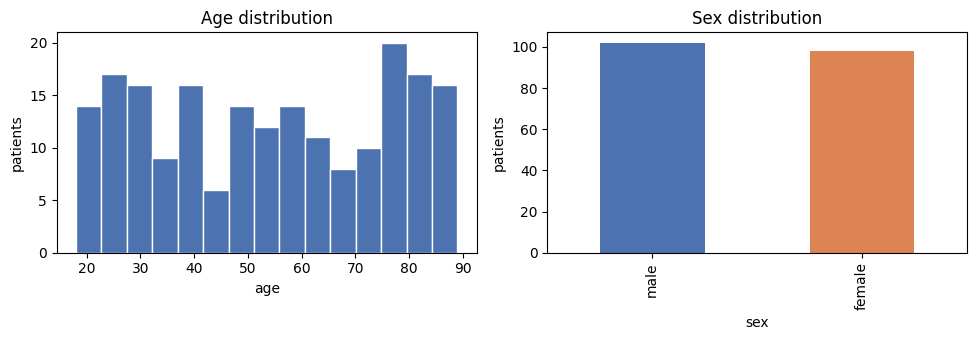

In [7]:
# This code produces two side-by-side visualizations summarizing the patient demographics.
import matplotlib.pyplot as plt

# Create a figure with 2 subplots (side by side), with a specified size
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

# Plot a histogram of patient ages on the first subplot
ax[0].hist(patients["age"], bins=15, color="#4C72B0", edgecolor="white")
ax[0].set_title("Age distribution")
ax[0].set_xlabel("age")
ax[0].set_ylabel("patients")

# Plot a bar chart of patient sex counts on the second subplot
sex_counts.plot(kind="bar", ax=ax[1], color=["#4C72B0", "#DD8452"])
ax[1].set_title("Sex distribution")
ax[1].set_ylabel("patients")

# Adjust layout so plots don’t overlap and display the figure
plt.tight_layout()
plt.show()

## 1.5 How the tables connect

The five tables form a small **relational model**. Every clinical fact links back
to a `patient_id`; encounters, observations, conditions, and medications hang off
the patient. Module 2 unpacks this structure in depth.


In [8]:
# This loop iterates through each DataFrame contained in the 'ehr' dictionary.
# For each table, it prints:
#   - the table's name (left-justified for alignment)
#   - the number of rows in that table
#   - a list of the column names in that table
for name, df in ehr.items():
    print(f"{name:14s} {df.shape[0]:5d} rows  |  columns: {list(df.columns)}")

patients         200 rows  |  columns: ['patient_id', 'given_name', 'family_name', 'sex', 'age', 'birth_year']
encounters       511 rows  |  columns: ['encounter_id', 'patient_id', 'encounter_type', 'date']
observations    1804 rows  |  columns: ['observation_id', 'encounter_id', 'patient_id', 'observation', 'value', 'unit', 'date']
conditions       304 rows  |  columns: ['condition_id', 'patient_id', 'condition']
medications      276 rows  |  columns: ['medication_id', 'patient_id', 'medication']


## Exercises

1. Regenerate the dataset with `seed=7` and confirm the patient count and columns
   are stable but the values differ.
2. Compute the share of patients aged 65+ -  a common denominator in geriatric
   and Medicare-related reporting.
3. Add a `birth_decade` column derived from `birth_year` and tabulate it.



## Key takeaways

- Informatics governs the **capture → store → exchange → use** lifecycle; analytics
  mostly consumes the result.
- Reproducibility starts with **pinned, reported versions**.
- Real health data is **relational and linked by patient** — the shape we profile next.



---
*Next: Module 2 - Health Data Types and Structure.*
